In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# Load training data
df = pd.read_csv("train.csv")
print("Training data shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

训练数据形状: (909, 7)

数据前5行:
   id  magnitude  depth  cdi  mmi  sig  label
0   1        6.9     25    4    4  -33      0
1   2        7.0    579    3    3  -13      0
2   3        6.6    624    0    2  -98      0
3   4        6.8    630    1    3  -57      0
4   5        6.7     20    7    6   29      0


In [ ]:
# Basic data information
print("="*50)
print("Basic Data Information Analysis")
print("="*50)
print(f"\nTotal number of samples: {len(df)}")
print(f"Number of features: {df.shape[1] - 2}")  # Excluding id and label
print(f"\nMissing values statistics:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)
print(f"\nDescriptive statistics for numerical features:")
print(df.describe())

数据基本信息分析

总样本数: 909
特征数: 5

缺失值统计:
id           0
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
label        0
dtype: int64

数据类型:
id             int64
magnitude    float64
depth          int64
cdi            int64
mmi            int64
sig            int64
label          int64
dtype: object

数值型特征的描述性统计:
               id   magnitude       depth         cdi         mmi         sig  \
count  909.000000  909.000000  909.000000  909.000000  909.000000  909.000000   
mean   455.000000    7.049329   53.306931    6.903190    6.885589  -11.007701   
std    262.549995    0.421836  111.468587    2.312931    1.406444   62.847387   
min      1.000000    6.500000    5.000000    0.000000    1.000000 -128.000000   
25%    228.000000    6.700000   12.000000    6.000000    6.000000  -57.000000   
50%    455.000000    6.970000   19.000000    8.000000    7.000000   -8.000000   
75%    682.000000    7.300000   38.000000    8.000000    8.000000   30.000000   
max    909.000000

标签分布分析

各标签的样本数量:
标签 0: 235 个样本 (25.85%)
标签 1: 232 个样本 (25.52%)
标签 2: 213 个样本 (23.43%)
标签 3: 229 个样本 (25.19%)


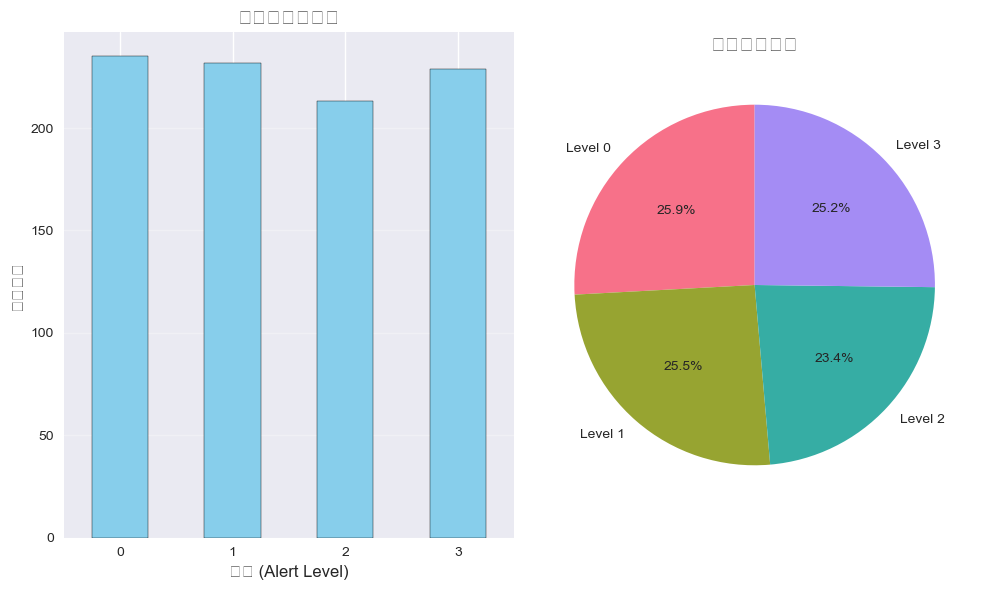

In [ ]:
# Label distribution analysis
print("="*50)
print("Label Distribution Analysis")
print("="*50)
label_counts = df['label'].value_counts().sort_index()
print(f"\nSample count for each label:")
for label in sorted(df['label'].unique()):
    count = label_counts[label]
    percentage = count / len(df) * 100
    print(f"Label {label}: {count} samples ({percentage:.2f}%)")

# Visualize label distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Label Distribution Bar Chart', fontsize=14, fontweight='bold')
plt.xlabel('Label (Alert Level)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.pie(label_counts.values, labels=[f'Level {i}' for i in label_counts.index], 
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("husl", 4))
plt.title('Label Distribution Pie Chart', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


特征分布分析


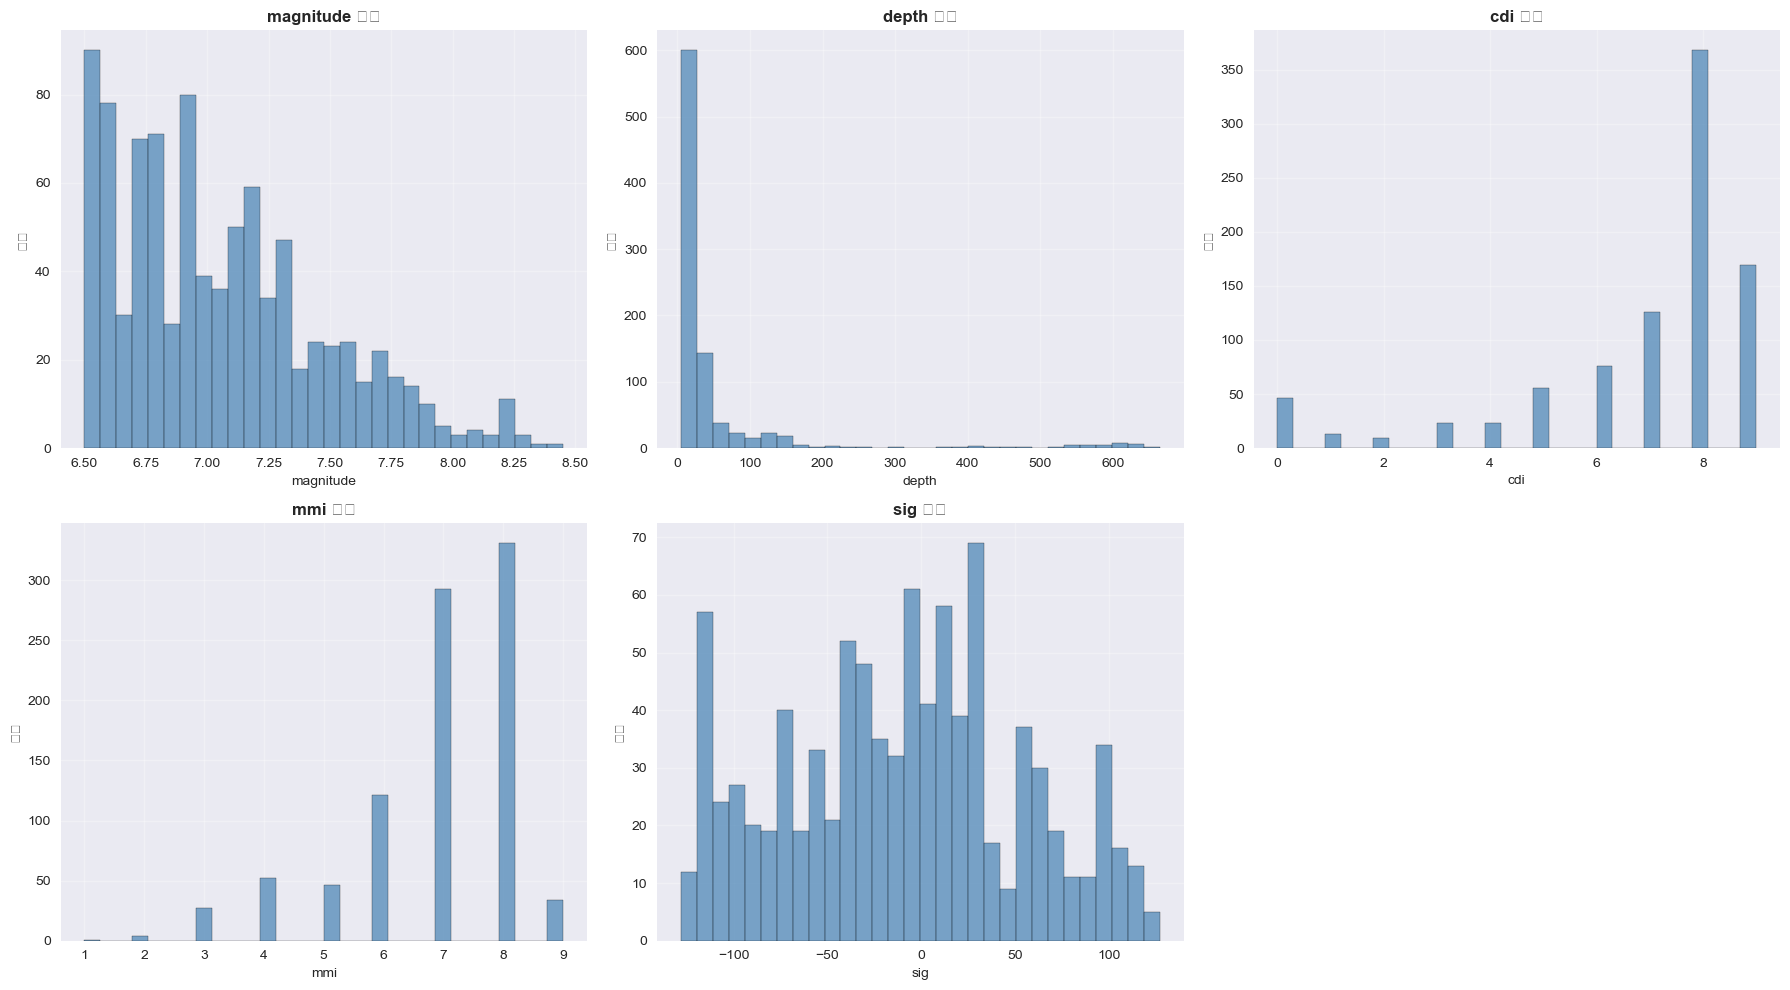


magnitude:
  均值: 7.0493
  标准差: 0.4218
  最小值: 6.5000
  最大值: 8.4500
  中位数: 6.9700

depth:
  均值: 53.3069
  标准差: 111.4686
  最小值: 5.0000
  最大值: 664.0000
  中位数: 19.0000

cdi:
  均值: 6.9032
  标准差: 2.3129
  最小值: 0.0000
  最大值: 9.0000
  中位数: 8.0000

mmi:
  均值: 6.8856
  标准差: 1.4064
  最小值: 1.0000
  最大值: 9.0000
  中位数: 7.0000

sig:
  均值: -11.0077
  标准差: 62.8474
  最小值: -128.0000
  最大值: 127.0000
  中位数: -8.0000


In [ ]:
# Feature analysis - distribution of numerical features
print("="*50)
print("Feature Distribution Analysis")
print("="*50)

feature_cols = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(alpha=0.3)

# Remove extra subplot
axes[5].axis('off')
plt.tight_layout()
plt.show()

# Print statistical information for each feature
for col in feature_cols:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.4f}")
    print(f"  Std: {df[col].std():.4f}")
    print(f"  Min: {df[col].min():.4f}")
    print(f"  Max: {df[col].max():.4f}")
    print(f"  Median: {df[col].median():.4f}")

特征相关性分析


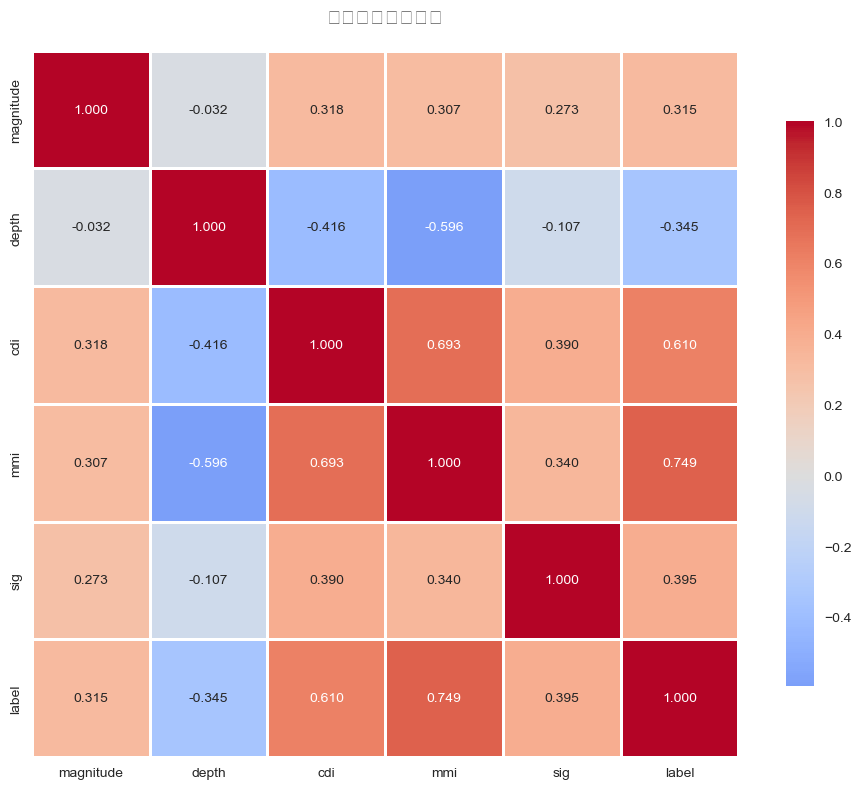


各特征与标签的相关系数:
  mmi: 0.7491
  cdi: 0.6102
  sig: 0.3952
  magnitude: 0.3153
  depth: -0.3453


In [ ]:
# Feature correlation analysis
print("="*50)
print("Feature Correlation Analysis")
print("="*50)

# Calculate correlation coefficients between features
corr_matrix = df[feature_cols + ['label']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation between features and label
print("\nCorrelation coefficients between features and label:")
label_corr = corr_matrix['label'].drop('label').sort_values(ascending=False)
for feature, corr in label_corr.items():
    print(f"  {feature}: {corr:.4f}")


不同标签下的特征分布对比


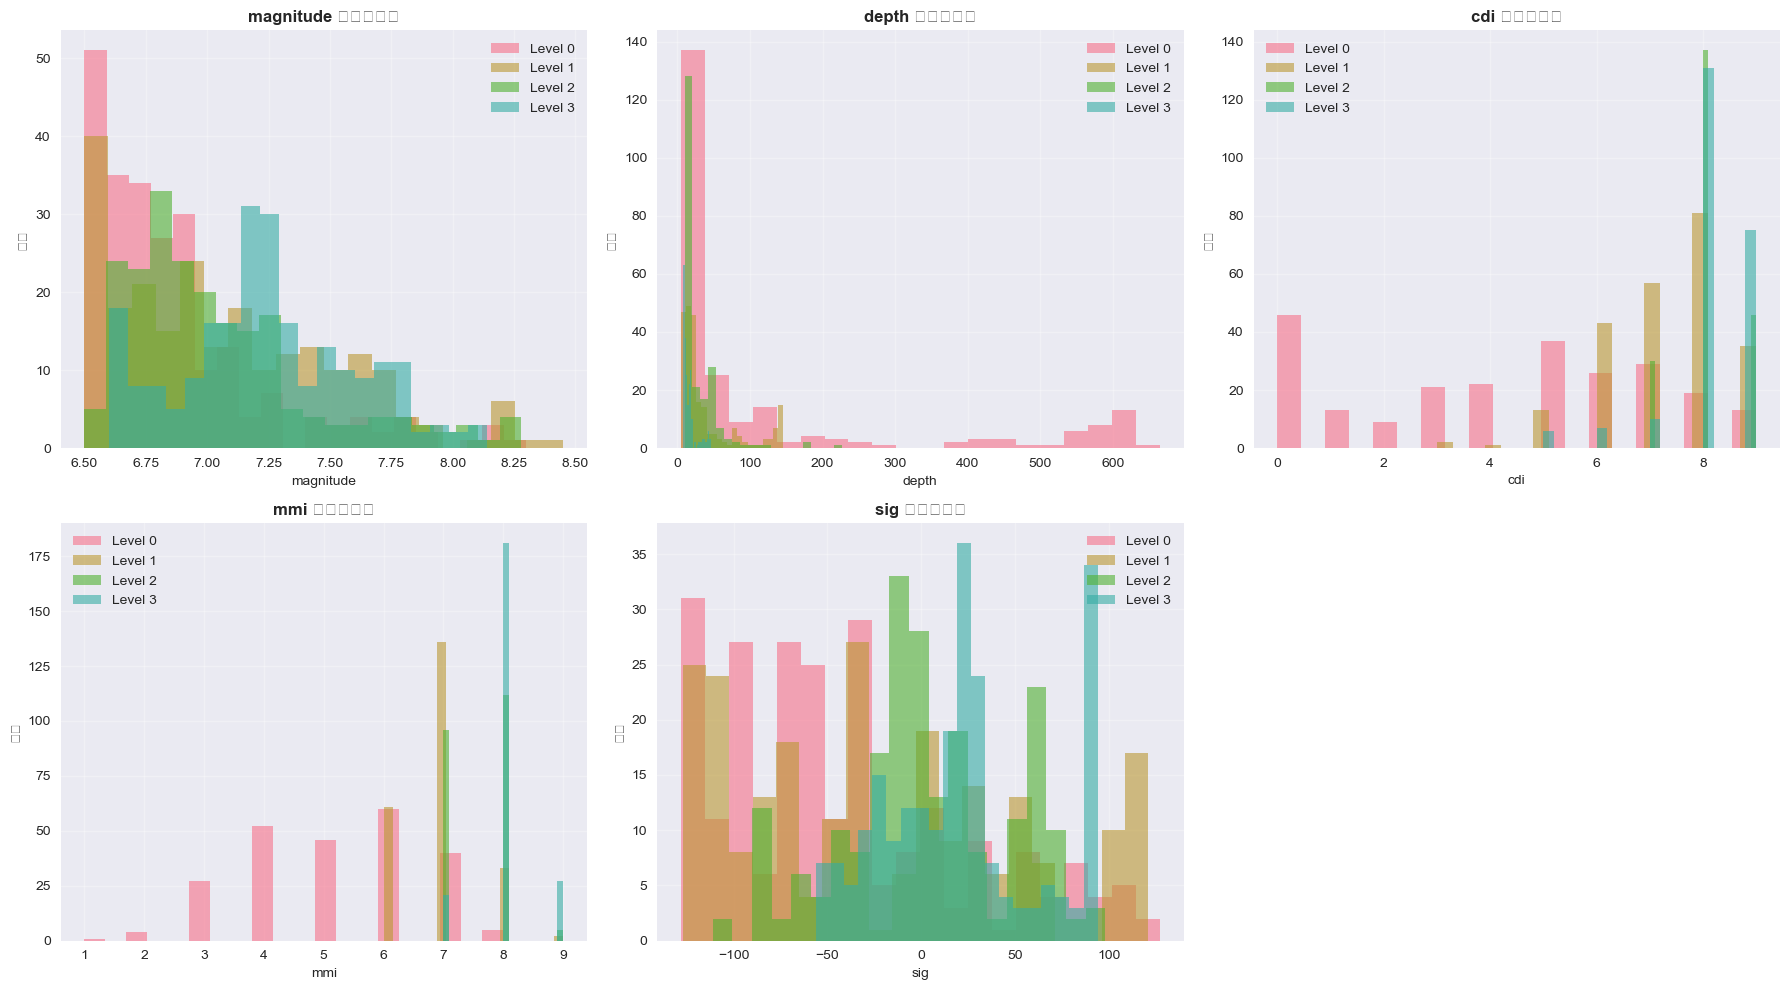

In [ ]:
# Feature distribution comparison by label
print("="*50)
print("Feature Distribution Comparison by Label")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    for label in sorted(df['label'].unique()):
        label_data = df[df['label'] == label][col]
        axes[idx].hist(label_data, bins=20, alpha=0.6, label=f'Level {label}')
    axes[idx].set_title(f'{col} Distribution by Label', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

axes[5].axis('off')
plt.tight_layout()
plt.show()


特征箱线图分析


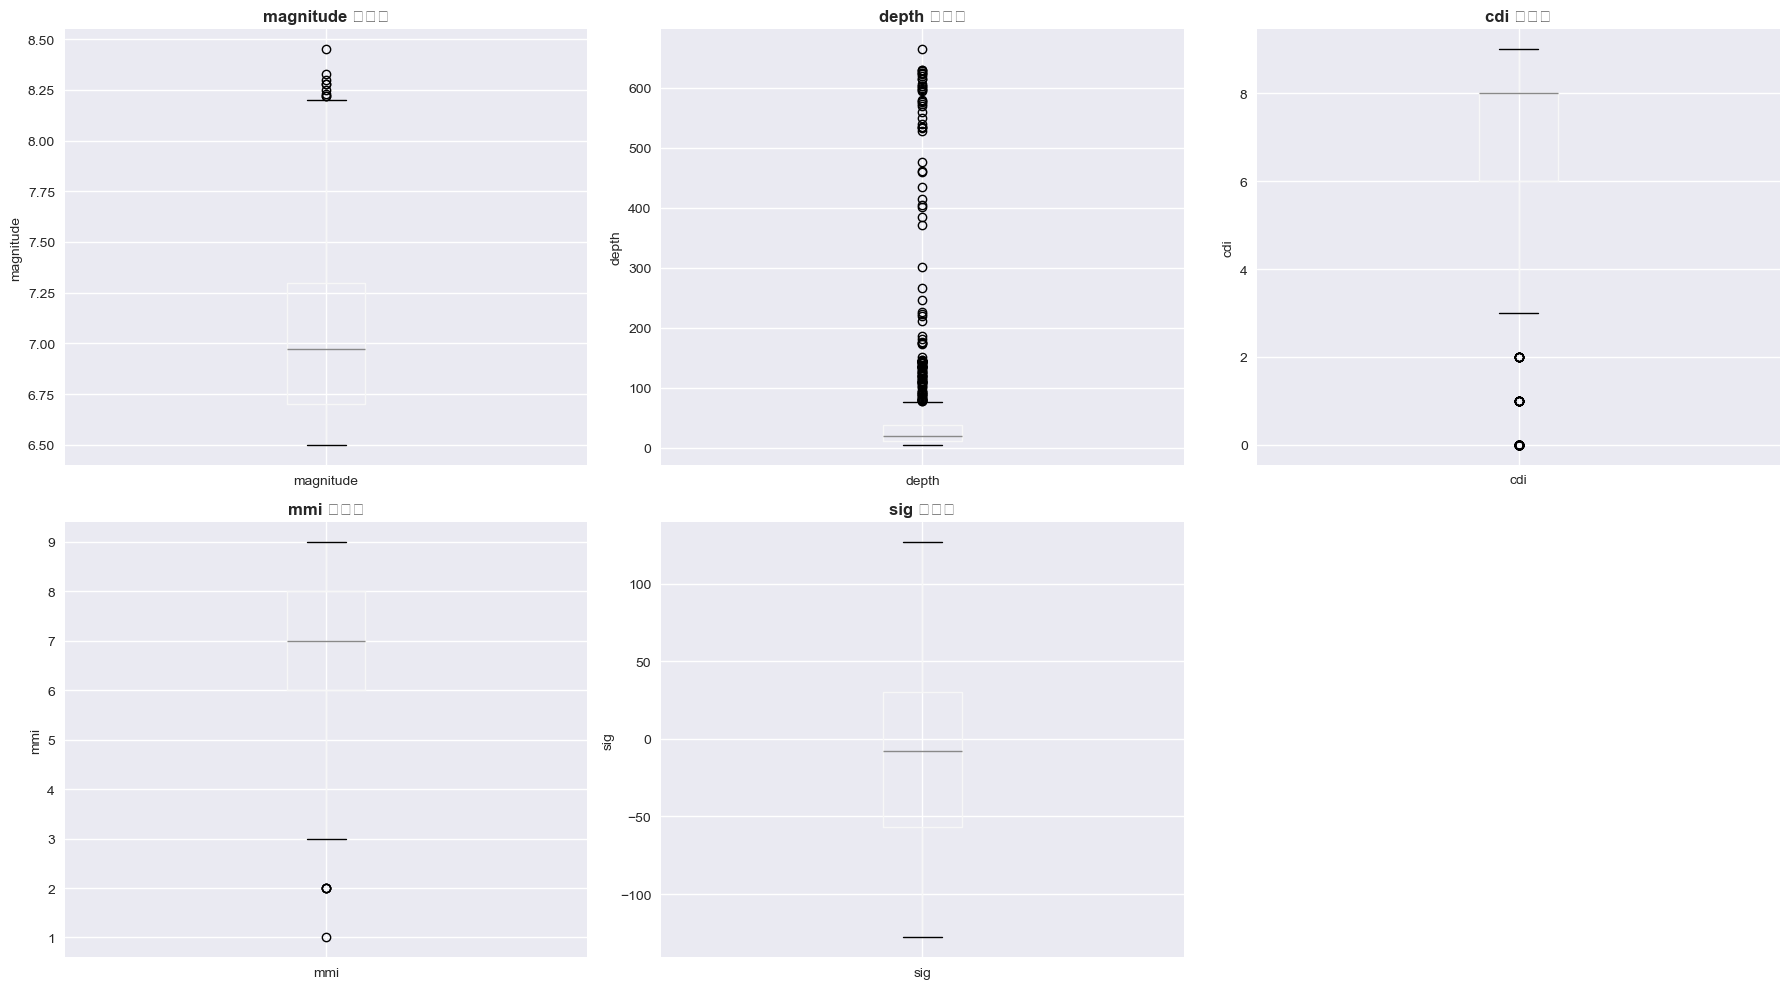

In [ ]:
# Boxplot analysis - check for outliers in features
print("="*50)
print("Feature Boxplot Analysis")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    df.boxplot(column=col, ax=axes[idx], grid=True)
    axes[idx].set_title(f'{col} Boxplot', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=10)

axes[5].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# Data Preprocessing
# ============================================================================

print("="*50)
print("Data Preprocessing")
print("="*50)

# Separate features and labels
X = df[feature_cols].values
y = df['label'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardized feature statistics:")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}")

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"\nTraining set label distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} samples ({c/len(y_train)*100:.2f}%)")


数据预处理

特征矩阵形状: (909, 5)
标签向量形状: (909,)

标准化后的特征统计:
均值: [-1.06307824e-15  3.12670071e-17 -9.38010212e-17  1.56335035e-16
 -1.56335035e-17]
标准差: [1. 1. 1. 1. 1.]

训练集大小: 727
验证集大小: 182

训练集标签分布:
  标签 0: 188 个样本 (25.86%)
  标签 1: 186 个样本 (25.58%)
  标签 2: 170 个样本 (23.38%)
  标签 3: 183 个样本 (25.17%)


In [ ]:
# ============================================================================
# Custom Deep Neural Network Implementation
# ============================================================================

# Define custom dataset class
class EarthquakeDataset(Dataset):
    """
    Custom dataset class for PyTorch DataLoader
    """
    def __init__(self, features, labels):
        """
        Initialize dataset
        Args:
            features: Feature array (n_samples, n_features)
            labels: Label array (n_samples,)
        """
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# Custom deep neural network class
class CustomDeepNeuralNetwork(nn.Module):
    """
    Custom deep neural network for earthquake alert level classification
    
    Network architecture:
    - Input layer: 5 features
    - Hidden layer 1: Fully connected + ReLU activation + Dropout
    - Hidden layer 2: Fully connected + ReLU activation + Dropout
    - Hidden layer 3: Fully connected + ReLU activation + Dropout
    - Output layer: Logits for 4 classes
    """
    def __init__(self, input_size=5, hidden_size1=128, hidden_size2=64, hidden_size3=32, 
                 num_classes=4, dropout_rate=0.3):
        """
        Initialize network
        Args:
            input_size: Input feature dimension (5)
            hidden_size1: Number of neurons in first hidden layer
            hidden_size2: Number of neurons in second hidden layer
            hidden_size3: Number of neurons in third hidden layer
            num_classes: Number of output classes (4)
            dropout_rate: Dropout rate
        """
        super(CustomDeepNeuralNetwork, self).__init__()
        
        # Layer 1: Input -> Hidden layer 1
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)  # Batch normalization for faster training
        self.relu1 = nn.ReLU()
        #self.dropout1 = nn.Dropout(dropout_rate)
        
        # Layer 2: Hidden layer 1 -> Hidden layer 2
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.relu2 = nn.ReLU()
        #self.dropout2 = nn.Dropout(dropout_rate)
        
        # Layer 3: Hidden layer 2 -> Hidden layer 3
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.relu3 = nn.ReLU()
        #self.dropout3 = nn.Dropout(dropout_rate)
        
        # Output layer: Hidden layer 3 -> Classes
        self.fc4 = nn.Linear(hidden_size3, num_classes)
    
    def forward(self, x):
        """
        Forward propagation
        Args:
            x: Input features (batch_size, input_size)
        Returns:
            Output logits (batch_size, num_classes)
        """
        # Layer 1
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        #out = self.dropout1(out)
        
        # Layer 2
        out = self.fc2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        #out = self.dropout2(out)
        
        # Layer 3
        out = self.fc3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        #out = self.dropout3(out)
        
        # Output layer (no activation function, softmax is applied automatically by CrossEntropyLoss)
        out = self.fc4(out)
        
        return out

# Print network structure
print("="*50)
print("Custom Deep Neural Network Architecture")
print("="*50)
model = CustomDeepNeuralNetwork()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


Custom Deep Neural Network Architecture
CustomDeepNeuralNetwork(
  (fc1): Linear(in_features=5, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)

Total parameters: 11236
Trainable parameters: 11236


In [25]:
# Create data loaders
train_dataset = EarthquakeDataset(X_train, y_train)
val_dataset = EarthquakeDataset(X_val, y_val)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")


Number of training batches: 23
Number of validation batches: 6


In [32]:
# ============================================================================
# Model Training
# ============================================================================

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = CustomDeepNeuralNetwork(
    input_size=5,
    hidden_size1=256,
    hidden_size2=128,
    hidden_size3=64,
    num_classes=4,
    dropout_rate=0.1
).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross-entropy loss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Adam optimizer
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training parameters
num_epochs = 200
best_val_f1 = 0.0
train_losses = []
val_losses = []
train_f1_scores = []
val_f1_scores = []

# Early stopping parameters
early_stopping_patience = 20  # Stop early if validation F1 doesn't improve for 20 epochs
early_stopping_counter = 0
best_epoch = 0

# Gradient clipping parameters
max_grad_norm = 1.0  # Gradient clipping threshold

print("="*50)
print("Starting Model Training")
print("="*50)
print(f"Maximum training epochs: {num_epochs}")
print(f"Early stopping patience: {early_stopping_patience}")
print(f"Gradient clipping threshold: {max_grad_norm}")
print("="*50)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_preds = []
    train_labels = []
    
    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping - prevent gradient explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        train_loss += loss.item()
        
        # Collect predictions
        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
    
    # Calculate training metrics
    avg_train_loss = train_loss / len(train_loader)
    train_f1 = f1_score(train_labels, train_preds, average='macro')
    train_losses.append(avg_train_loss)
    train_f1_scores.append(train_f1)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    # Calculate validation metrics
    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    val_losses.append(avg_val_loss)
    val_f1_scores.append(val_f1)
    
    # Update learning rate
    scheduler.step(avg_val_loss)
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        early_stopping_counter = 0  # Reset counter
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'\n✓ Epoch [{epoch+1}/{num_epochs}] - Better model found!')
        print(f'  Train Loss: {avg_train_loss:.4f}, Train F1: {train_f1:.4f}')
        print(f'  Val Loss: {avg_val_loss:.4f}, Val F1: {val_f1:.4f} (New Best)')
    else:
        early_stopping_counter += 1
    
    # Print every 10 epochs (if best model not updated)
    if (epoch + 1) % 10 == 0:
        if val_f1 <= best_val_f1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {avg_train_loss:.4f}, Train F1: {train_f1:.4f}')
            print(f'  Val Loss: {avg_val_loss:.4f}, Val F1: {val_f1:.4f}')
            print(f'  Learning Rate: {current_lr:.6f}, Early Stop Counter: {early_stopping_counter}/{early_stopping_patience}')
    
    # Early stopping check
    if early_stopping_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered! Validation F1 didn't improve for {early_stopping_patience} epochs.")
        print(f"Best model at epoch {best_epoch}, F1 score: {best_val_f1:.4f}")
        break

print("\n" + "="*50)
print(f"Training completed! Best validation F1 score: {best_val_f1:.4f} (Epoch {best_epoch})")
print(f"Total epochs trained: {epoch + 1}")
print("="*50)


Using device: cpu
Starting Model Training
Maximum training epochs: 200
Early stopping patience: 20
Gradient clipping threshold: 1.0

✓ Epoch [1/200] - Better model found!
  Train Loss: 1.1525, Train F1: 0.4639
  Val Loss: 0.9020, Val F1: 0.4881 (New Best)

✓ Epoch [2/200] - Better model found!
  Train Loss: 0.8254, Train F1: 0.6387
  Val Loss: 0.8076, Val F1: 0.6023 (New Best)

✓ Epoch [3/200] - Better model found!
  Train Loss: 0.7083, Train F1: 0.7020
  Val Loss: 0.7376, Val F1: 0.6698 (New Best)

✓ Epoch [4/200] - Better model found!
  Train Loss: 0.6683, Train F1: 0.6979
  Val Loss: 0.7252, Val F1: 0.7128 (New Best)

✓ Epoch [7/200] - Better model found!
  Train Loss: 0.5737, Train F1: 0.7902
  Val Loss: 0.6758, Val F1: 0.7248 (New Best)

✓ Epoch [8/200] - Better model found!
  Train Loss: 0.5567, Train F1: 0.7811
  Val Loss: 0.6679, Val F1: 0.7272 (New Best)

✓ Epoch [9/200] - Better model found!
  Train Loss: 0.5323, Train F1: 0.8081
  Val Loss: 0.6085, Val F1: 0.7406 (New Best)


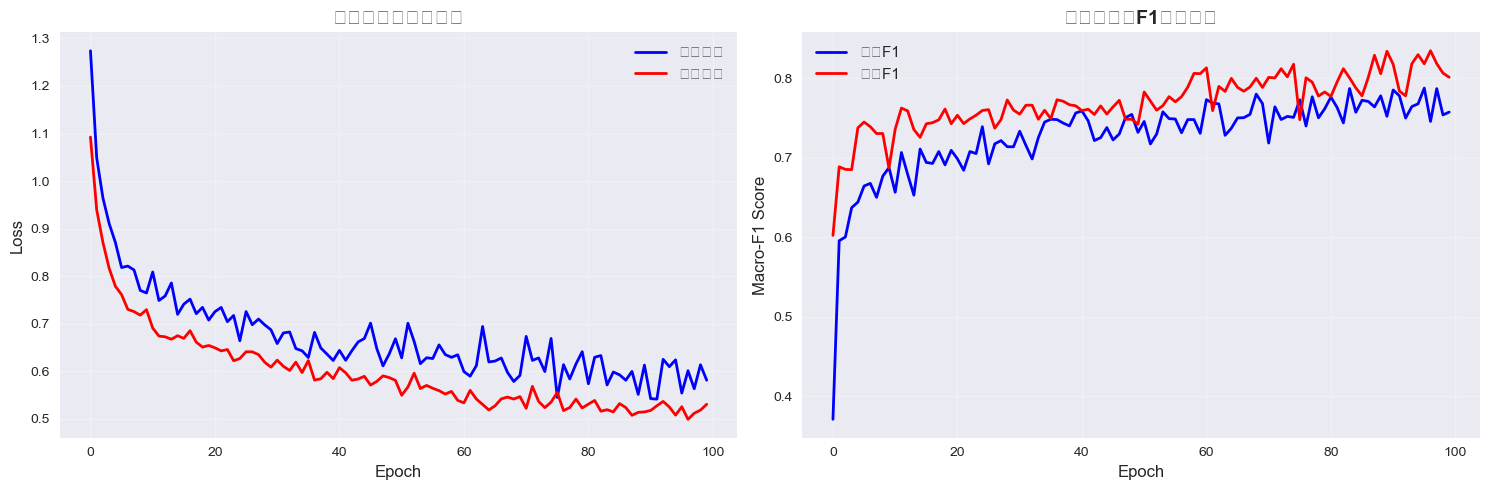

In [ ]:
# Visualize training process
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='red', linewidth=2)
axes[0].set_title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# F1 score curves
axes[1].plot(train_f1_scores, label='Train F1', color='blue', linewidth=2)
axes[1].plot(val_f1_scores, label='Val F1', color='red', linewidth=2)
axes[1].set_title('Training and Validation F1 Score Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Macro-F1 Score', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


验证集分类报告
              precision    recall  f1-score   support

     Level 0       0.97      0.77      0.86        47
     Level 1       0.76      0.83      0.79        46
     Level 2       0.91      0.74      0.82        43
     Level 3       0.77      1.00      0.87        46

    accuracy                           0.84       182
   macro avg       0.85      0.83      0.83       182
weighted avg       0.85      0.84      0.83       182



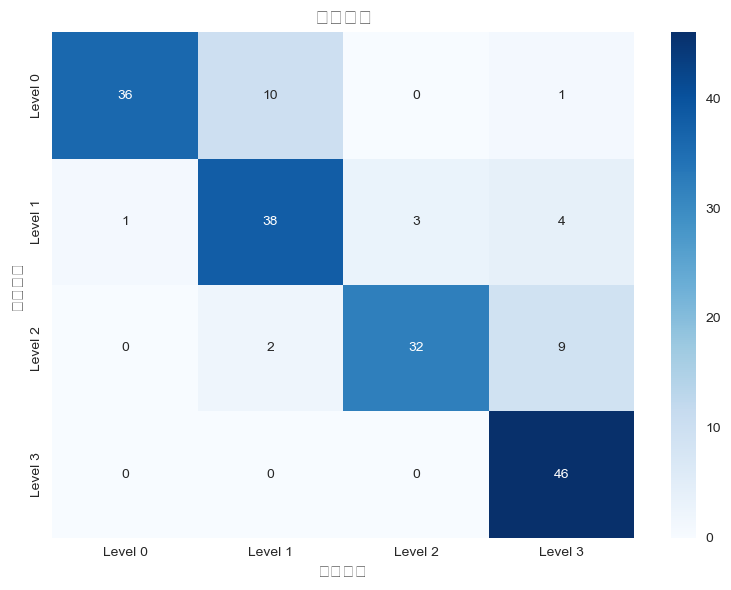


最终Macro-F1分数: 0.8343


In [ ]:
# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Make predictions on validation set
val_preds = []
val_labels = []

with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = model(features)
        _, preds = torch.max(outputs, 1)
        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

# Calculate detailed classification report
print("="*50)
print("Validation Set Classification Report")
print("="*50)
print(classification_report(val_labels, val_preds, target_names=[f'Level {i}' for i in range(4)]))

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Level {i}' for i in range(4)],
            yticklabels=[f'Level {i}' for i in range(4)])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nFinal Macro-F1 Score: {f1_score(val_labels, val_preds, average='macro'):.4f}")


In [ ]:
# ============================================================================
# Make Predictions on Test Data
# ============================================================================

print("="*50)
print("Load Test Data and Make Predictions")
print("="*50)

# Load test data
test_df = pd.read_csv("test.csv")
print(f"Test data shape: {test_df.shape}")
print(f"\nFirst 5 rows of test data:")
print(test_df.head())

# Extract features and standardize
X_test = test_df[feature_cols].values
X_test_scaled = scaler.transform(X_test)  # Use the scaler from training

# Create test dataset
test_dataset = EarthquakeDataset(X_test_scaled, np.zeros(len(X_test_scaled)))  # Labels filled with 0, won't be used
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Make predictions
model.eval()
test_predictions = []

with torch.no_grad():
    for features, _ in test_loader:
        features = features.to(device)
        outputs = model(features)
        _, preds = torch.max(outputs, 1)
        test_predictions.extend(preds.cpu().numpy())

# View prediction result distribution
print(f"\nPrediction result distribution:")
unique, counts = np.unique(test_predictions, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} samples ({c/len(test_predictions)*100:.2f}%)")

# Generate submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'label': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\nSubmission file saved as 'submission.csv'")
print(f"\nFirst 10 rows of submission file:")
print(submission.head(10))


In [ ]:
# Validate submission file format
sample_submission = pd.read_csv("sample_submission.csv")
print("="*50)
print("Validate Submission File Format")
print("="*50)
print(f"Sample submission file shape: {sample_submission.shape}")
print(f"Generated submission file shape: {submission.shape}")
print(f"\nColumn names match: {list(submission.columns) == list(sample_submission.columns)}")
print(f"\nID range check:")
print(f"  Sample file ID range: {sample_submission['id'].min()} - {sample_submission['id'].max()}")
print(f"  Generated file ID range: {submission['id'].min()} - {submission['id'].max()}")
print(f"\nLabel range check:")
print(f"  Sample file label range: {sample_submission['label'].min()} - {sample_submission['label'].max()}")
print(f"  Generated file label range: {submission['label'].min()} - {submission['label'].max()}")
print(f"\nFormat validation passed! ✓")
